In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pandas_datareader import data as pdr
import warnings
warnings.filterwarnings('ignore')

start = "2010-01-01"
end = "2024-01-01"

series = {
    "CPIAUCSL": "cpi",      
    "UNRATE": "unrate",     
    "FEDFUNDS": "fedfunds",
    "INDPRO": "indpro",
    "M2SL": "m2"
}

df_list = []
for code, name in series.items():
    s = pdr.DataReader(code, "fred", start, end)
    s.columns = [name]
    df_list.append(s)

df = pd.concat(df_list, axis=1).resample("MS").mean().dropna()
display(df.head())

,cpi,unrate,fedfunds,indpro,m2
DATE,,,,,
2010-01-01,217.488,9.8,0.11,89.3426,8477.7
2010-02-01,217.281,9.8,0.13,89.6779,8527.3
2010-03-01,217.353,9.9,0.16,90.2928,8523.5
2010-04-01,217.403,9.9,0.20,90.5991,8554.8
2010-05-01,217.290,9.6,0.20,91.8230,8609.0


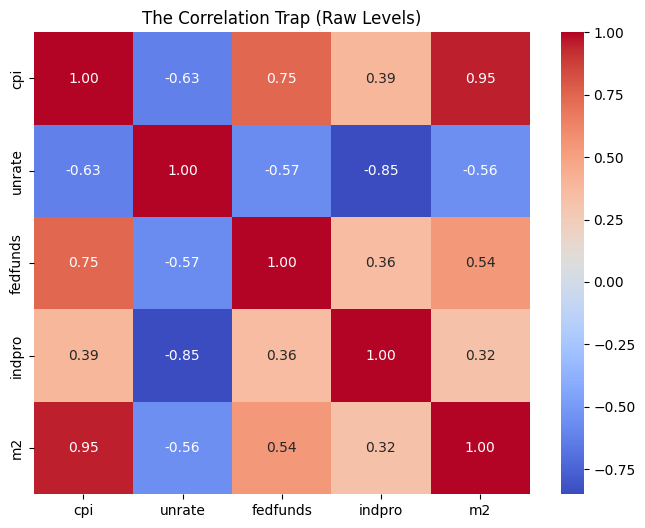

In [3]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("The Correlation Trap (Raw Levels)")
plt.show()

In [4]:
# Define predictors (X). We leave out CPI as it is our theoretical target.
X = df[['unrate', 'fedfunds', 'indpro', 'm2']]
X = sm.add_constant(X) # Statsmodels requires a constant for VIF

# Calculate VIF iteratively
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

display(vif_data)

,Feature,VIF
0,const,4252.825829
1,unrate,6.206882
2,fedfunds,1.727582
3,indpro,4.290455
4,m2,1.780273


In [ ]:
df_t = df.copy()

# Transform trending variables to YoY growth (%)
for col in ["cpi", "indpro", "m2"]:
    df_t[f"{col}_yoy"] = 100 * (df_t[col] / df_t[col].shift(12) - 1)

# Drop missing values created by the 12-month shift
df_t = df_t.dropna()

# Visualize the corrected correlations
cols_to_keep = ['cpi_yoy', 'unrate', 'fedfunds', 'indpro_yoy', 'm2_yoy']
plt.figure(figsize=(8, 6))
sns.heatmap(df_t[cols_to_keep].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Structurally Sound Correlation (YoY Growth)")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# --- 1. Mock Data Generation (Replace this block with your actual DataFrame) ---
np.random.seed(42)
dates = pd.date_range(start='2010-01-01', periods=120, freq='M')

# Simulating highly trending "raw" data (prone to spurious correlation)
raw_data = pd.DataFrame({
    'CPI': np.linspace(100, 150, 120) + np.random.normal(0, 1, 120),
    'Unemployment': np.linspace(10, 3, 120) + np.random.normal(0, 0.5, 120),
    'Fed_Funds': np.linspace(0.1, 5, 120) + np.random.normal(0, 0.2, 120),
    'Industrial_Production': np.linspace(90, 110, 120) + np.random.normal(0, 1.5, 120),
    'M2': np.linspace(8000, 20000, 120) + np.random.normal(0, 100, 120)
}, index=dates)

# Calculating YoY growth rates (stationary, mitigating spurious correlation)
yoy_data = raw_data.pct_change(periods=12).dropna() * 100

# --- 2. Calculate Correlation Matrices ---
corr_raw = raw_data.corr().round(2)
corr_yoy = yoy_data.corr().round(2)

# --- 3. Build Plotly Interactive Heatmap ---

# Initialize the figure with the Raw correlation matrix
fig = go.Figure(data=go.Heatmap(
    z=corr_raw.values,
    x=corr_raw.columns,
    y=corr_raw.index,
    colorscale='RdBu',
    zmin=-1, zmax=1,            # Locks the color scale so it doesn't shift between views
    texttemplate="%{z}",        # Automatically displays the correlation values
    textfont={"size": 14}
))

# Define the dropdown menu buttons
buttons = [
    dict(
        label="Raw Levels Correlation",
        method="restyle",       # Modifies the data of the existing trace
        args=[{"z": [corr_raw.values]}] # Passes the new z-data matrix
    ),
    dict(
        label="YoY Growth Correlation",
        method="restyle",
        args=[{"z": [corr_yoy.values]}]
    )
]

# Add the dropdown menu and format the layout
fig.update_layout(
    title="Macroeconomic Correlation Matrix: Raw Levels vs. YoY Growth",
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            showactive=True,
            x=0.5,
            xanchor="center",
            y=1.15,
            yanchor="top"
        )
    ],
    width=800,
    height=600,
    yaxis=dict(autorange="reversed") # Reverses Y-axis to match standard matrix orientation
)

# Display the dashboard
fig.show()